In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

import random

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
df = pd.read_csv("dt_n/WineQT.csv")

print("Forma del dataset:", df.shape)

Forma del dataset: (1143, 13)


In [4]:
print("Primeras filas del dataset:", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Primeras filas del dataset: None


In [5]:
datos_modelo = df.copy()

print("Dataset original:", df.shape)
print("Copia para el modelo:", datos_modelo.shape)

Dataset original: (1143, 13)
Copia para el modelo: (1143, 13)


In [6]:
datos_modelo = datos_modelo.drop(columns=['Id'])

In [7]:
datos_modelo.shape

(1143, 12)

In [8]:
from sklearn.preprocessing import LabelEncoder

X = datos_modelo.drop(columns=["quality"])
y = datos_modelo["quality"]

print(y.value_counts())

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy= 'auto', k_neighbors=2, random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("Después de SMOTE:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDistribución de clases:")
print(y_train.value_counts())

Después de SMOTE:
X_train: (2316, 11)
y_train: (2316,)

Distribución de clases:
quality
5    386
7    386
6    386
4    386
8    386
3    386
Name: count, dtype: int64


In [11]:
print("Después de SMOTE:")
print("y_train:", y_train.shape)
print("y_train:", y_train.value_counts())
print("y_train:", y_train.value_counts(normalize=True))

Después de SMOTE:
y_train: (2316,)
y_train: quality
5    386
7    386
6    386
4    386
8    386
3    386
Name: count, dtype: int64
y_train: quality
5    0.166667
7    0.166667
6    0.166667
4    0.166667
8    0.166667
3    0.166667
Name: proportion, dtype: float64


In [12]:
cantidad_clases = y_train.nunique()

print("Cantidad total de clases:", cantidad_clases)

Cantidad total de clases: 6


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

print("Clases originales:", encoder.classes_)
print("Clases para PyTorch:", sorted(set(y_train)))

Clases originales: [3 4 5 6 7 8]
Clases para PyTorch: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [14]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [15]:
X_train, mu, sigma = featureNormalize(X_train)

X_test = (X_test - mu) / sigma

In [16]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [17]:
import torch

X_train_t = torch.tensor(
    X_train,
    dtype=torch.float32
).cuda()

X_test_t = torch.tensor(
    X_test,
    dtype=torch.float32
).cuda()

y_train_t = torch.tensor(
    y_train,
    dtype=torch.long
).cuda()

y_test_t = torch.tensor(
    y_test,
    dtype=torch.long
).cuda()

In [ ]:
D_in, H1,  D_out = 11, 10, 6
model = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, D_out),
).cuda()

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)

epochs = 2000
log_each = 10

l = []
val_l = []          # <<< NUEVO: guardamos la pérdida de validación por epoch

best_val_loss = float("inf")   # <<< NUEVO: mejor pérdida de validación vista hasta ahora
patience = 10                 # <<< NUEVO: epochs de tolerancia sin mejora antes de parar
step = 0                       # <<< NUEVO: contador de epochs sin mejora


model.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred = model(X_train_t)

    # Loss
    loss = criterion(
        y_pred,
        y_train_t
    )

    l.append(loss.item())

    # Ponemos a cero los gradientes
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Actualizamos los pesos
    optimizer.step()


    # <<< NUEVO: bloque completo de validación + early stopping >>>
    model.eval()
    with torch.no_grad():
            val_logits = model(X_test_t)
            val_loss = criterion(
                val_logits,
                y_test_t
            )
    val_l.append(val_loss.item())
    
    if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            torch.save(model.state_dict(), "ckpt_desba.pt")
            step = 0
    else:
            step += 1
    
    if step > patience:
            print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
            break
        # <<< FIN bloque nuevo >>>


    if not e % log_each:
            print(
                f"Epoch {e}/{epochs} "
                f"Loss {loss.item():.5f} "
                f"Val_loss {val_loss.item():.5f}"     # <<< NUEVO en el print
            )
    
    model.load_state_dict(torch.load("ckpt_desba.pt"))

Epoch 10/2000 Loss 1.74420 Val_loss 1.75436
Epoch 20/2000 Loss 1.72026 Val_loss 1.74603
Epoch 30/2000 Loss 1.69663 Val_loss 1.73790
Epoch 40/2000 Loss 1.67300 Val_loss 1.72999
Epoch 50/2000 Loss 1.64916 Val_loss 1.72214
Epoch 60/2000 Loss 1.62422 Val_loss 1.71426
Epoch 70/2000 Loss 1.59836 Val_loss 1.70652
Epoch 80/2000 Loss 1.57188 Val_loss 1.69874
Epoch 90/2000 Loss 1.54498 Val_loss 1.69064
Epoch 100/2000 Loss 1.51791 Val_loss 1.68221
Epoch 110/2000 Loss 1.49098 Val_loss 1.67307
Epoch 120/2000 Loss 1.46459 Val_loss 1.66293
Epoch 130/2000 Loss 1.43887 Val_loss 1.65182
Epoch 140/2000 Loss 1.41399 Val_loss 1.63984
Epoch 150/2000 Loss 1.38996 Val_loss 1.62706
Epoch 160/2000 Loss 1.36686 Val_loss 1.61372
Epoch 170/2000 Loss 1.34480 Val_loss 1.59982
Epoch 180/2000 Loss 1.32374 Val_loss 1.58576
Epoch 190/2000 Loss 1.30374 Val_loss 1.57182
Epoch 200/2000 Loss 1.28480 Val_loss 1.55812
Epoch 210/2000 Loss 1.26692 Val_loss 1.54471
Epoch 220/2000 Loss 1.25003 Val_loss 1.53178
Epoch 230/2000 Loss

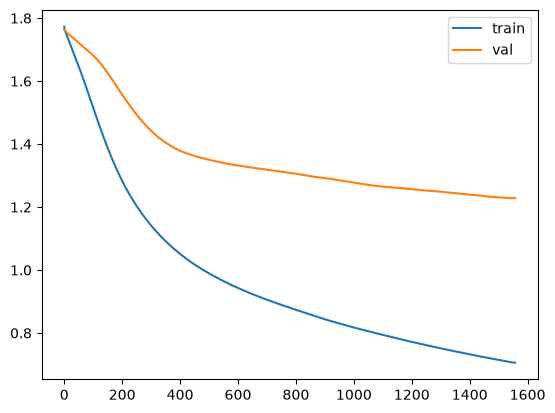

In [35]:
plt.plot(l, label="train")
plt.plot(val_l, label="val")
plt.legend()

In [36]:
from sklearn.metrics import accuracy_score

def evaluate(x):

    model.eval()

    logits = model(x)

    probabilidades = torch.softmax(logits, dim=1)

    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [37]:
y_pred = evaluate(
    X_test_t
)

accuracy_emnist = accuracy_score(
    y_test_t.cpu().numpy(),
    y_pred.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 49.34%
